In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [3]:
df=pd.read_csv("depression_data_outliers_removed.csv")

In [4]:
df.head()

,Name,Age,Marital Status,Education Level,Number of Children,Smoking Status,Physical Activity Level,Employment Status,Income,Alcohol Consumption,Dietary Habits,Sleep Patterns,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,Christine Barker,31,Married,Bachelor's Degree,2,Non-smoker,Active,Unemployed,26265.67,Moderate,Moderate,Fair,Yes,No,Yes,Yes
1,Jacqueline Lewis,55,Married,High School,1,Non-smoker,Sedentary,Employed,42710.36,High,Unhealthy,Fair,Yes,No,No,Yes
2,Shannon Church,78,Widowed,Master's Degree,1,Non-smoker,Sedentary,Employed,125332.79,Low,Unhealthy,Good,No,No,Yes,No
3,Charles Jordan,58,Divorced,Master's Degree,3,Non-smoker,Moderate,Unemployed,9992.78,Moderate,Moderate,Poor,No,No,No,No
4,Michael Rich,18,Single,High School,0,Non-smoker,Sedentary,Unemployed,8595.08,Low,Moderate,Fair,Yes,No,Yes,Yes


In [5]:
numerical_columns=['Age','Number of Children','Income']
df[numerical_columns].describe()

,Age,Number of Children,Income
count,408611.000000,408611.000000,408611.000000
mean,48.956036,1.295929,48967.606699
std,18.192314,1.236509,37924.576364
min,18.000000,0.000000,0.410000
25%,33.000000,0.000000,20742.770000
50%,49.000000,1.000000,37011.400000
75%,65.000000,2.000000,74032.860000
max,80.000000,4.000000,160022.000000


In [6]:
standard_scaler=StandardScaler()
df_standard=df.copy()

df_standard[numerical_columns]=standard_scaler.fit_transform(df[numerical_columns])
df_standard[numerical_columns].head()

,Age,Number of Children,Income
0,-0.987013,0.569403,-0.598608
1,0.332227,-0.239327,-0.164992
2,1.596498,-0.239327,2.013609
3,0.497132,1.378132,-1.027694
4,-1.701602,-1.048056,-1.064549


In [7]:
minmax_scaler=MinMaxScaler()
df_minmax=df.copy()

df_minmax[numerical_columns]=minmax_scaler.fit_transform(df[numerical_columns])
df_minmax[numerical_columns].head()

,Age,Number of Children,Income
0,0.209677,0.50,0.164136
1,0.596774,0.25,0.266901
2,0.967742,0.25,0.783222
3,0.645161,0.75,0.062444
4,0.000000,0.00,0.053709


In [8]:
comparision=pd.DataFrame({
    'Original Age':df['Age'].head(),
    'Standard Age':df_standard['Age'].head(),
    'MinMax Age':df_minmax['Age'].head()
})
comparision

,Original Age,Standard Age,MinMax Age
0,31,-0.987013,0.209677
1,55,0.332227,0.596774
2,78,1.596498,0.967742
3,58,0.497132,0.645161
4,18,-1.701602,0.000000


In [9]:
corr_df=df[['Age','Number of Children','Income','History of Mental Illness','History of Substance Abuse','Family History of Depression','Chronic Medical Conditions']].copy()

binary_columns=['History of Mental Illness','History of Substance Abuse','Family History of Depression','Chronic Medical Conditions']
for i in binary_columns:
    corr_df[i]=corr_df[i].map({'No':0,'Yes':1})

corr_df.head()

,Age,Number of Children,Income,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
0,31,2,26265.67,1,0,1,1
1,55,1,42710.36,1,0,0,1
2,78,1,125332.79,0,0,1,0
3,58,3,9992.78,0,0,0,0
4,18,0,8595.08,1,0,1,1


In [10]:
correlation_matrix=corr_df.corr()
correlation_matrix.round(2)

,Age,Number of Children,Income,History of Mental Illness,History of Substance Abuse,Family History of Depression,Chronic Medical Conditions
Age,1.00,0.26,-0.08,0.03,-0.02,0.11,-0.02
Number of Children,0.26,1.00,0.02,0.00,-0.01,0.08,-0.01
Income,-0.08,0.02,1.00,-0.14,0.00,-0.01,-0.03
History of Mental Illness,0.03,0.00,-0.14,1.00,0.00,0.00,0.01
History of Substance Abuse,-0.02,-0.01,0.00,0.00,1.00,-0.00,0.00
Family History of Depression,0.11,0.08,-0.01,0.00,-0.00,1.00,-0.00
Chronic Medical Conditions,-0.02,-0.01,-0.03,0.01,0.00,-0.00,1.00


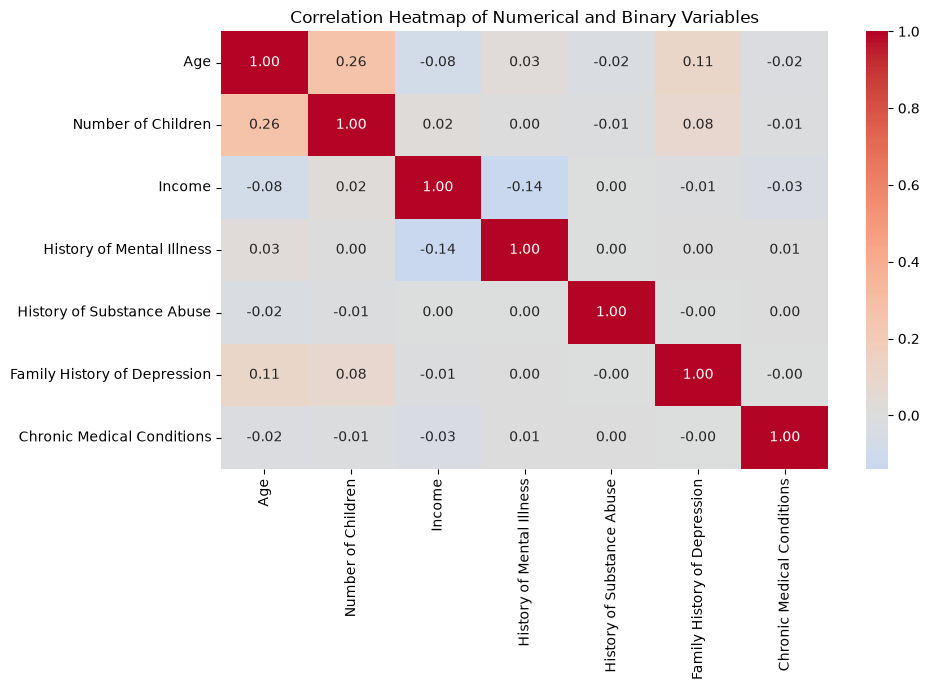

In [12]:
plt.figure(figsize=(10,7))

sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Correlation Heatmap of Numerical and Binary Variables")
plt.tight_layout()
plt.show()

In [13]:
df_standard.to_csv("depression_standardize.csv",index=False)
df_minmax.to_csv("depression_minmax.csv",index=False)